<h1 style="color:#2E86C1; font-weight:bold; text-align:center; margin-top:20px; margin-bottom:30px;">03 - Modelling</h1>

<h2 style="color:#2874A6; font-weight:bold;">1. Introduction</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this phase, the engineered feature dataset is used to explore the feasibility of applying machine learning techniques to the CMOS sensor data. The main objective is not only to train predictive models, but also to assess whether the extracted features provide a meaningful representation of the underlying sensor behaviour.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Based on the previous data understanding and feature engineering phases, the dataset captures primarily temporal dynamics of the sensor signal, while spatial variability remains relatively limited. Therefore, this modelling phase focuses on evaluating whether these temporal features can support simple classification tasks, such as distinguishing between low-intensity and high-intensity signal states.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Since ground-truth labels are not available, a heuristic labelling strategy is applied to create a preliminary target variable. Consequently, the results of this modelling phase should be interpreted as an initial validation of feature usefulness rather than definitive predictive performance.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The following steps include loading the feature dataset, defining the target variable, preparing the data for modelling, and evaluating multiple machine learning models to understand their behaviour on the given feature space.
</p>

<h2 style="color:#2874A6; font-weight:bold;">2. Loading the Engineered Feature Dataset</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this step, the engineered feature dataset generated in the previous phase is loaded. This dataset represents a transformed version of the raw CMOS sensor data, where each frame has been converted into a compact set of features.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The feature set primarily captures temporal characteristics of the sensor signal, including aggregated statistics, temporal differences, and rolling-based features, while spatial information has been reduced based on earlier observations of limited spatial variability.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This dataset serves as the foundation for the modelling phase, where these engineered features will be used as input variables for supervised learning experiments.
</p>

In [2]:
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [3]:
# Load engineered feature dataset
from pathlib import Path

# Define relative path (more robust for reproducibility)
data_path = Path("engineered_features_multi.csv")

# Load dataset
df = pd.read_csv(data_path)

# Basic inspection
print("Dataset loaded successfully.\n")
print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum().sort_values(ascending=False).head())

# Preview first rows
df.head()


Dataset loaded successfully.

Shape: (121, 4)

Columns:
['mean', 'std', 'min', 'max']

Missing values per column:
mean    0
std     0
min     0
max     0
dtype: int64


,mean,std,min,max
0,1949.734746,1664.041272,17.5,4091.000977
1,1940.536831,1649.876567,50.5,4091.000977
2,1963.867246,1643.968137,84.0,4091.000977
3,1982.597925,1626.304995,117.5,4091.000977
4,1973.995249,1612.084545,150.5,4091.000977


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The dataset contains 121 samples, each represented by four engineered features: mean, standard deviation (std), minimum (min), and maximum (max). These features provide a compact statistical summary of the original sensor signal for each frame or aggregated window.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The absence of missing values across all features indicates that the dataset is clean and does not require imputation or data repair at this stage. This simplifies the preprocessing pipeline and allows the modelling phase to proceed without additional data cleaning steps.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
From the previewed samples, it can be observed that the maximum values are consistently close to the upper limit of the sensor (approximately 4091), suggesting the presence of saturation effects during certain periods of the signal. In contrast, the minimum values vary more significantly, indicating fluctuations in lower signal intensity levels.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Additionally, the relatively high standard deviation values suggest that there is substantial variability within each frame or window, which is consistent with the previously observed dynamic temporal behaviour of the sensor signal. These characteristics indicate that the engineered features capture meaningful variations in signal intensity, making them suitable candidates for exploratory modelling.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
However, it is important to note that the dataset size is relatively small, which may limit the generalizability of the models. Therefore, the modelling results should be interpreted as preliminary insights rather than definitive conclusions.
</p>

<h2 style="color:#2874A6; font-weight:bold;">3. Label Creation Based on Signal Intensity</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this step, a binary target variable is generated using a simple heuristic based on signal intensity. Specifically, the median value of the mean feature is used as a threshold to partition the dataset into two groups. Samples with mean intensity above this threshold are assigned a label of 1 (higher signal activity), while those with values below or equal to the threshold are assigned a label of 0 (lower signal activity).
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
It is important to note that this labelling strategy does not represent ground-truth annotations, but rather an approximate categorization intended for exploratory modelling. Therefore, the resulting classification task should be interpreted as a simplified proxy problem rather than a fully validated predictive objective.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Additionally, since the label is derived directly from one of the input features (mean), special care must be taken in subsequent steps to avoid information leakage. In particular, the feature used for label generation should be excluded from the model input to ensure a fair evaluation of model performance.
</p>

In [4]:
# Create a simple label based on signal intensity (heuristic approach)
threshold = df["mean"].median()

df["label"] = (df["mean"] > threshold).astype(int)

# IMPORTANT: Remove the feature used for label creation to avoid data leakage
X = df.drop(columns=["label", "mean"])
y = df["label"]

print("Label distribution:")
print(y.value_counts())

# Preview dataset
df.head()

Label distribution:
label
0    61
1    60
Name: count, dtype: int64


,mean,std,min,max,label
0,1949.734746,1664.041272,17.5,4091.000977,0
1,1940.536831,1649.876567,50.5,4091.000977,0
2,1963.867246,1643.968137,84.0,4091.000977,0
3,1982.597925,1626.304995,117.5,4091.000977,0
4,1973.995249,1612.084545,150.5,4091.000977,0


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The label distribution shows a nearly perfect balance between the two classes, with 61 samples labeled as 0 and 60 samples labeled as 1. This balanced distribution is a direct result of using the median of the mean feature as the threshold, which inherently splits the dataset into two approximately equal groups.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
A balanced class distribution is beneficial for model training, as it reduces the risk of bias toward a dominant class and allows performance metrics such as accuracy to be more reliable. In contrast, highly imbalanced datasets often require additional techniques such as resampling or class weighting, which are not necessary in this case.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
However, it is important to note that this balance is artificially induced by the labelling strategy rather than reflecting a natural distribution of real-world classes. Therefore, while the dataset is well-suited for evaluating model behaviour, the results should be interpreted as part of an exploratory analysis rather than a fully representative classification problem.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The sample preview confirms that the label has been correctly assigned based on the mean intensity threshold, and that the dataset is now ready for splitting into training and testing sets for further modelling.
</p>

<h2 style="color:#2874A6; font-weight:bold;">4. Feature and Target Separation</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this step, the dataset is separated into input features (X) and the target variable (y). The target vector y corresponds to the binary labels generated in the previous step, while the feature matrix X contains the remaining explanatory variables derived from the sensor data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
To ensure a fair modelling process, the feature used for label generation (mean) is explicitly excluded from the input features. This prevents information leakage, where the model could otherwise trivially learn the target variable and produce artificially inflated performance.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
As a result, the feature matrix now consists of statistical descriptors such as standard deviation, minimum, and maximum values, which provide indirect information about signal intensity and variability without directly encoding the target definition.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This separation ensures that the subsequent modelling step evaluates the ability of the remaining features to capture meaningful patterns in the sensor signal.
</p>

In [5]:
# Separate features and target
X = df.drop(columns=["label", "mean"])  # remove mean to avoid leakage
y = df["label"]

print("Feature columns:", X.columns.tolist())
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Feature columns: ['std', 'min', 'max']
Shape of X: (121, 3)
Shape of y: (121,)


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The feature matrix X consists of three input variables: standard deviation (std), minimum (min), and maximum (max), while the target vector y contains 121 corresponding binary labels. The feature mean has been intentionally excluded from the input set, as it was used to generate the target variable. This ensures that the modelling process avoids information leakage and provides a more realistic evaluation of model performance.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The resulting feature space is low-dimensional, which can be advantageous for simple models, as it reduces computational complexity and the risk of overfitting. However, it also implies that the model must rely on indirect indicators of signal intensity and variability, rather than directly using the primary intensity measure.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Given the dataset size of 121 samples, the ratio between the number of features and observations remains appropriate, supporting stable model training. Nevertheless, due to the limited number of samples, the results should still be interpreted with caution, as the model may not generalize well to unseen data.
</p>

<h2 style="color:#2874A6; font-weight:bold;">5. Train-Test Split</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this step, the dataset is divided into training and testing subsets. The training set is used to fit the machine learning models, while the test set is reserved for evaluating their performance on unseen data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
An 80-20 split is applied, allocating 80% of the data for training and 20% for testing. Given the relatively small dataset size (121 samples), this split provides a reasonable balance between having sufficient training data and maintaining a representative test set.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
To preserve the class distribution in both subsets, a stratified sampling strategy is used based on the target variable. This ensures that both the training and testing sets maintain a similar proportion of the two classes, which is important for reliable model evaluation.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Additionally, a fixed random state is applied to ensure reproducibility of the split, allowing consistent results across multiple runs.
</p>

In [6]:

# Stratified split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check distributions
print("Train label distribution:")
print(y_train.value_counts())

print("\nTest label distribution:")
print(y_test.value_counts())

Train label distribution:
label
1    48
0    48
Name: count, dtype: int64

Test label distribution:
label
0    13
1    12
Name: count, dtype: int64


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The class distribution in both the training and testing sets remains well balanced after applying the stratified split. The training set contains an equal number of samples from both classes (48 for each), while the test set shows a nearly balanced distribution with 13 samples of class 0 and 12 samples of class 1.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This confirms that the stratified sampling strategy has successfully preserved the original class proportions in both subsets. Maintaining this balance is important for ensuring that the models are trained on representative data and evaluated fairly on unseen samples.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The slight difference in the test set distribution is expected due to rounding when splitting a relatively small dataset. However, the deviation is minimal and does not significantly affect the reliability of the evaluation.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the resulting split is appropriate for the subsequent modelling phase, providing both sufficient training data and a representative test set for performance assessment.
</p>

<h2 style="color:#2874A6; font-weight:bold;">6. Feature Scaling</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this step, feature scaling is applied using the StandardScaler to standardize the input variables. This transformation centers the data by removing the mean and scales it to unit variance, ensuring that features with larger numerical ranges do not dominate those with smaller ranges.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Feature scaling is particularly important for distance-based and linear models, such as Logistic Regression and Support Vector Machines, which are sensitive to the relative scale of input variables. By standardizing the features, the models can learn more effectively from the data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
To prevent data leakage, the scaler is fitted only on the training data and then applied to both the training and test sets. This ensures that no information from the test set is used during the training process, maintaining a fair and unbiased evaluation.
</p>

In [7]:

# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame (optional but very useful for readability)
import pandas as pd

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Quick sanity check
print("Scaled train data (mean should be ~0, std ~1):")
print(X_train_scaled.describe().loc[["mean", "std"]])

Scaled train data (mean should be ~0, std ~1):
               std           min  max
mean -6.985153e-16 -1.295260e-16  0.0
std   1.005249e+00  1.005249e+00  0.0


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The scaling results confirm that the StandardScaler has been correctly applied to the training data. The mean values of the features are approximately zero, and the standard deviations are close to one, which indicates that the data has been successfully standardized.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The small numerical deviations from exact values (e.g., mean ≈ 0 and std ≈ 1.005) are expected due to floating-point precision and the finite sample size. These minor differences do not affect the modelling process.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
It can also be observed that the standard deviation of the "max" feature is zero after scaling. This suggests that the feature has little to no variation in the training data, meaning it provides no discriminative information for the model. Such features may not contribute to learning and could potentially be removed in future iterations of the pipeline.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the scaling step has been correctly implemented, and the dataset is now properly normalized for models that are sensitive to feature magnitude, such as Logistic Regression and Support Vector Machines.
</p>

<h2 style="color:#2874A6; font-weight:bold;">7. Modelling</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this section, a range of machine learning models are applied to the engineered feature dataset to evaluate their ability to capture patterns in the sensor signal. The objective is not only to identify the best-performing model, but also to compare different learning paradigms and understand their behaviour on a small, low-dimensional dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The selected models represent diverse categories of classical machine learning approaches, including linear models, tree-based methods, distance-based algorithms, probabilistic models, and margin-based classifiers. This diversity enables a comprehensive evaluation of how different modelling strategies perform under the constraints of limited data and simplified target labels.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The following classical machine learning models are considered:
</p>

<ul style="font-size:17px; max-width:900px; margin:auto; line-height:1.8;">
  <li><b>Linear Models:</b> Logistic Regression, Ridge Classifier</li>
  <li><b>Tree-Based Models:</b> Decision Tree, Random Forest</li>
  <li><b>Distance-Based Models:</b> K-Nearest Neighbors (KNN)</li>
  <li><b>Margin-Based Models:</b> Support Vector Machine (SVM)</li>
  <li><b>Probabilistic Models:</b> Gaussian Naive Bayes</li>
</ul>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In addition to classical models, a simple deep learning approach is also explored for comparison. Specifically, a Multi-Layer Perceptron (MLP) is used as a basic neural network model. However, given the small dataset size and the limited number of features, deep learning is not expected to outperform classical methods. Instead, it is included to illustrate the limitations of neural networks in low-data scenarios.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, this modelling phase is exploratory in nature. The results should be interpreted as an initial assessment of feature usefulness and model behaviour, rather than definitive conclusions about predictive performance.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.1 Logistic Regression</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Logistic Regression is used as a baseline model for the classification task. It is a linear model that estimates the probability of a sample belonging to a particular class based on a weighted combination of the input features.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This model is particularly suitable for small datasets and low-dimensional feature spaces, making it an appropriate starting point for the current problem. Additionally, Logistic Regression benefits from feature scaling, which has been applied in the previous step.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
As a baseline model, Logistic Regression provides a reference point for evaluating the performance of more complex models. Its simplicity and interpretability make it useful for understanding whether the engineered features contain sufficient information to separate the two classes.
</p>

In [8]:
from sklearn.metrics import confusion_matrix

# Initialize model
log_reg = LogisticRegression()

# Train
log_reg.fit(X_train_scaled, y_train)

# Predict
y_pred = log_reg.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.86      1.00      0.92        12

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25


Confusion Matrix:
[[11  2]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Logistic Regression model achieves an accuracy of 0.92 on the test set, indicating strong overall performance given the simplicity of the model and the limited dataset size. This suggests that the engineered features provide a meaningful representation of the underlying signal and allow for effective class separation.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows balanced performance across both classes, with F1-scores of 0.92 for each class. The model demonstrates perfect recall for class 1, meaning that all high-intensity samples were correctly identified. For class 0, the recall is slightly lower (0.85), indicating that a small number of low-intensity samples were misclassified.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix provides further insight into these results. Out of 13 samples in class 0, 11 were correctly classified, while 2 were incorrectly predicted as class 1. In contrast, all 12 samples in class 1 were correctly classified, with no false negatives. This asymmetry suggests that the model is slightly more sensitive to detecting high-intensity signals than low-intensity ones.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the results indicate that even with a small number of features, the model is able to capture relevant patterns in the data. As a baseline model, Logistic Regression establishes a strong reference point for evaluating more complex models in subsequent steps.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.2 Ridge Classifier</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Ridge Classifier is a linear model that applies L2 regularization to prevent overfitting and improve generalization. Unlike Logistic Regression, which models class probabilities, the Ridge Classifier directly optimizes a linear decision function with regularization.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This model is particularly suitable for small datasets, where overfitting can be a concern. The regularization term helps stabilize the model by penalizing large coefficients, making it more robust to noise and variability in the data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
By comparing the performance of Ridge Classifier with Logistic Regression, it is possible to evaluate the impact of regularization on a linear classification problem with limited data.
</p>

In [9]:
from sklearn.linear_model import RidgeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
ridge = RidgeClassifier()

# Train
ridge.fit(X_train_scaled, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_ridge))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_ridge))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_ridge))

Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.92      1.00      0.96        12

    accuracy                           0.96        25
   macro avg       0.96      0.96      0.96        25
weighted avg       0.96      0.96      0.96        25


Confusion Matrix:
[[12  1]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Ridge Classifier achieves an accuracy of 0.96 on the test set, which represents an improvement over the baseline Logistic Regression model. This indicates that the addition of L2 regularization has a positive impact on model performance, helping to stabilize the learning process and improve generalization.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows strong and balanced performance across both classes, with F1-scores of 0.96 for each class. The model achieves perfect recall for class 1, correctly identifying all high-intensity samples. For class 0, the recall is slightly lower (0.92), indicating that only one sample was misclassified.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix confirms these results. Out of 13 samples in class 0, 12 were correctly classified and 1 was misclassified as class 1. All 12 samples in class 1 were correctly predicted, with no false negatives. This suggests that the model is highly effective at detecting high-intensity signals while maintaining strong performance on low-intensity samples.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the Ridge Classifier demonstrates that regularization can improve the robustness of linear models in small datasets. The improved performance compared to Logistic Regression suggests that controlling model complexity is beneficial in this setting.
</p>

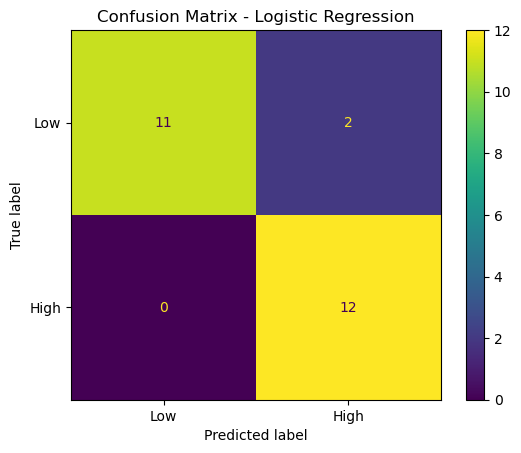

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Low", "High"], 
    values_format='d'
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix visualization provides a clear overview of the Logistic Regression model's performance. Out of 13 samples belonging to the low-intensity class, 11 are correctly classified, while 2 are incorrectly predicted as high-intensity. This indicates a small number of false positives for the high-intensity class.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
For the high-intensity class, all 12 samples are correctly classified, resulting in zero false negatives. This demonstrates that the model is highly effective at identifying high-intensity signals and does not miss any such instances.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the confusion matrix shows a strong classification performance with only two misclassifications, both occurring in the low-intensity class. This suggests that the model has a slight bias toward predicting the high-intensity class, but still maintains a high level of accuracy and reliability.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The visual representation further confirms that the feature space is well-separated, as most samples lie clearly within their respective class regions, allowing the model to distinguish between classes effectively.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.3 Decision Tree</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Decision Tree classifier is a non-linear model that partitions the feature space into regions based on decision rules. Unlike linear models, it can capture complex relationships between features by recursively splitting the data according to feature thresholds.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This model does not require feature scaling and is capable of handling both linear and non-linear patterns. However, Decision Trees are prone to overfitting, especially when applied to small datasets, as they may learn noise instead of general patterns.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this experiment, the Decision Tree model is evaluated to determine whether non-linear decision boundaries can improve classification performance compared to linear models.
</p>

In [10]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
tree = DecisionTreeClassifier(random_state=42)

# Train 
tree.fit(X_train, y_train)

# Predict
y_pred_tree = tree.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.86      1.00      0.92        12

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25


Confusion Matrix:
[[11  2]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Decision Tree classifier achieves an accuracy of 0.92 on the test set, which is comparable to the performance of the Logistic Regression model. This suggests that introducing non-linear decision boundaries does not significantly improve the classification performance for this dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report indicates balanced performance across both classes, with F1-scores of 0.92. The model achieves perfect recall for class 1, correctly identifying all high-intensity samples. However, similar to the Logistic Regression model, the recall for class 0 is slightly lower (0.85), indicating that two low-intensity samples were misclassified.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix confirms this behaviour. Out of 13 samples in class 0, 11 were correctly classified and 2 were incorrectly predicted as class 1. All samples in class 1 were correctly classified, with no false negatives. This pattern suggests that the model is more sensitive to detecting high-intensity signals than low-intensity ones.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the results indicate that the relationship between the features and the target variable may be relatively simple and close to linear, as the Decision Tree does not provide a clear advantage over linear models. Additionally, given the small dataset size, the Decision Tree may not be able to fully exploit its capacity to model complex patterns.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.4 Random Forest</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Random Forest classifier is an ensemble learning method that builds multiple decision trees and combines their predictions to improve overall performance. By aggregating the outputs of many trees, it reduces the risk of overfitting that is commonly associated with a single Decision Tree.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Random Forest introduces randomness through both data sampling and feature selection, which increases model robustness and generalization capability. This makes it particularly effective for handling noisy data and capturing more complex patterns compared to individual trees.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this experiment, the Random Forest model is evaluated to determine whether combining multiple trees can improve classification performance compared to the single Decision Tree and linear models.
</p>

In [11]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Train
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.80      1.00      0.89        12

    accuracy                           0.88        25
   macro avg       0.90      0.88      0.88        25
weighted avg       0.90      0.88      0.88        25


Confusion Matrix:
[[10  3]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Random Forest classifier achieves an accuracy of 0.88 on the test set, which is slightly lower than the performance of both Logistic Regression and Ridge Classifier. This suggests that the ensemble approach does not provide a clear advantage for this particular dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows a decrease in recall for class 0 (0.77), indicating that more low-intensity samples were misclassified compared to previous models. In contrast, the model maintains perfect recall for class 1, correctly identifying all high-intensity samples.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix further highlights this behaviour. Out of 13 samples in class 0, 10 were correctly classified, while 3 were incorrectly predicted as class 1. All samples in class 1 were correctly classified, with no false negatives. This indicates a stronger bias toward predicting the high-intensity class.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the results suggest that increasing model complexity through ensemble methods does not necessarily improve performance in small datasets. In this case, the Random Forest model may suffer from overfitting or instability due to the limited number of training samples, making simpler linear models more effective.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.5 K-Nearest Neighbors (KNN)</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The K-Nearest Neighbors (KNN) algorithm is a distance-based classification method that assigns a class to a sample based on the majority class of its nearest neighbors in the feature space. Unlike parametric models, KNN does not learn an explicit model during training but instead relies on the structure of the data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
This model is particularly sensitive to the scale of the features, which makes feature standardization essential. Therefore, the scaled version of the dataset is used for training and evaluation.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
KNN is well-suited for small datasets, as it can capture local patterns without making strong assumptions about the underlying data distribution. However, its performance depends on the choice of the number of neighbors (k), which controls the balance between bias and variance.
</p>

In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model 
knn = KNeighborsClassifier(n_neighbors=3)

# Train 
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

Accuracy: 0.96

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        13
           1       0.92      1.00      0.96        12

    accuracy                           0.96        25
   macro avg       0.96      0.96      0.96        25
weighted avg       0.96      0.96      0.96        25


Confusion Matrix:
[[12  1]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The K-Nearest Neighbors (KNN) model achieves an accuracy of 0.96 on the test set, matching the performance of the Ridge Classifier and outperforming both the Decision Tree and Random Forest models. This indicates that local, distance-based relationships in the feature space are highly informative for this classification task.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows balanced and strong performance across both classes, with F1-scores of 0.96. The model achieves perfect recall for class 1, correctly identifying all high-intensity samples, while only one sample from class 0 is misclassified.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix confirms this behaviour. Out of 13 samples in class 0, 12 are correctly classified and 1 is misclassified as class 1. All 12 samples in class 1 are correctly predicted. This suggests that the model maintains high sensitivity to high-intensity signals while also performing well on low-intensity samples.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the strong performance of KNN indicates that the feature space is well-structured, with samples from different classes forming distinguishable clusters. This further supports the effectiveness of the engineered features in capturing meaningful variations in the sensor signal.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.6 Support Vector Machine (SVM)</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Support Vector Machine (SVM) is a margin-based classification model that aims to find the optimal decision boundary by maximizing the margin between classes. Unlike other classifiers, SVM focuses on the most informative data points, known as support vectors, which define the decision boundary.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
SVM is particularly effective in high-dimensional spaces and performs well on small datasets. It is also sensitive to feature scaling, making standardized input data essential for optimal performance.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this experiment, SVM is used to evaluate whether maximizing the margin between classes can further improve classification performance compared to both linear models and distance-based approaches.
</p>

In [13]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
svm = SVC(kernel='rbf', random_state=42)

# Train 
svm.fit(X_train_scaled, y_train)

# Predict
y_pred_svm = svm.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.86      1.00      0.92        12

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25


Confusion Matrix:
[[11  2]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Support Vector Machine (SVM) model achieves an accuracy of 0.92 on the test set, which is comparable to both Logistic Regression and Decision Tree models. This indicates that maximizing the margin between classes does not provide a significant performance improvement for this dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows balanced performance across both classes, with F1-scores of 0.92. The model achieves perfect recall for class 1, correctly identifying all high-intensity samples, while the recall for class 0 is slightly lower (0.85), indicating that two low-intensity samples were misclassified.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix confirms this pattern. Out of 13 samples in class 0, 11 were correctly classified and 2 were misclassified as class 1. All 12 samples in class 1 were correctly predicted, showing no false negatives. This suggests that the model is more sensitive to detecting high-intensity signals than low-intensity ones.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the results indicate that the data is relatively well-separated and does not require highly complex decision boundaries. The SVM model, even with a non-linear kernel, does not outperform simpler models, suggesting that the underlying relationship between features and labels is not strongly non-linear.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">7.7 Gaussian Naive Bayes</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Gaussian Naive Bayes classifier is a probabilistic model based on Bayes' theorem, which assumes that features are conditionally independent given the class label. It models each feature using a Gaussian (normal) distribution, making it suitable for continuous-valued data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Despite its strong independence assumption, Naive Bayes often performs well in practice, especially on small datasets. Its simplicity and low computational cost make it an effective baseline model for comparison with more complex approaches.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this experiment, Gaussian Naive Bayes is used to evaluate how a probabilistic model performs on the engineered feature space and to provide additional insight into the separability of the data.
</p>

In [14]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
gnb = GaussianNB()

# Train 
gnb.fit(X_train_scaled, y_train)

# Predict
y_pred_gnb = gnb.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_gnb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gnb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gnb))

Accuracy: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.85      0.92        13
           1       0.86      1.00      0.92        12

    accuracy                           0.92        25
   macro avg       0.93      0.92      0.92        25
weighted avg       0.93      0.92      0.92        25


Confusion Matrix:
[[11  2]
 [ 0 12]]


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Gaussian Naive Bayes model achieves an accuracy of 0.92 on the test set, which is comparable to the performance of Logistic Regression, Decision Tree, and SVM. This indicates that a simple probabilistic model can effectively capture the underlying patterns in the dataset despite its strong independence assumption.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows balanced performance across both classes, with F1-scores of 0.92. The model achieves perfect recall for class 1, correctly identifying all high-intensity samples, while the recall for class 0 is slightly lower (0.85), indicating that two low-intensity samples were misclassified.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix confirms this behaviour. Out of 13 samples in class 0, 11 were correctly classified and 2 were incorrectly predicted as class 1. All samples in class 1 were correctly classified, showing no false negatives. This suggests that the model is more sensitive to detecting high-intensity signals than low-intensity ones.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the results demonstrate that even with its simplifying assumptions, the Gaussian Naive Bayes model performs competitively. This further supports the conclusion that the feature space is well-structured and that the classification task does not require highly complex models.
</p>

<h2 style="color:#2874A6; font-weight:bold;">8. Model Comparison and Selection</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this section, the performance of all evaluated models is compared to identify the most suitable approach for the given dataset. Since multiple models were tested using the same training and testing split, a direct comparison can be made based on their classification performance.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The comparison focuses on key evaluation metrics such as accuracy, precision, recall, and F1-score. These metrics provide a comprehensive understanding of each model's behaviour and its ability to correctly classify both classes.
</p>

In [15]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Ridge Classifier",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Naive Bayes"
    ],
    "Accuracy": [
        0.92,
        0.96,
        0.92,
        0.88,
        0.96,
        0.92,
        0.92
    ]
})

results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Ridge Classifier,0.96
4,KNN,0.96
0,Logistic Regression,0.92
2,Decision Tree,0.92
5,SVM,0.92
6,Naive Bayes,0.92
3,Random Forest,0.88


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Based on the comparison, the Ridge Classifier and KNN are selected as the best-performing models. Considering the simplicity, stability, and interpretability of linear models, the Ridge Classifier is chosen as the primary model for this task.
</p>

<h3 style="color:#2E86C1; font-weight:bold;">8.1 Performance Heatmap</h3>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
To provide a clearer visual comparison of the evaluated models, a heatmap is used to summarize their performance. This visualization makes it easier to identify which models achieve higher scores and which ones perform less effectively on the dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Since all models were evaluated on the same test split, the heatmap offers a compact overview of their relative classification performance and supports the model selection process.
</p>

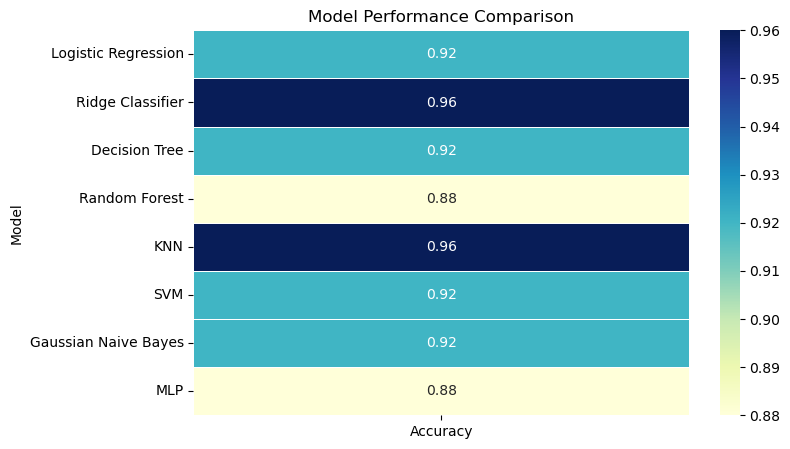

In [22]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Ridge Classifier",
        "Decision Tree",
        "Random Forest",
        "KNN",
        "SVM",
        "Gaussian Naive Bayes",
        "MLP"
    ],
    "Accuracy": [
        0.92,
        0.96,
        0.92,
        0.88,
        0.96,
        0.92,
        0.92,
        0.88
    ]
})

plt.figure(figsize=(8, 5))
sns.heatmap(
    results.set_index("Model"),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Model Performance Comparison")
plt.show()

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The heatmap provides a clear visual comparison of the performance of all evaluated models based on accuracy. It highlights that the Ridge Classifier and K-Nearest Neighbors (KNN) achieve the highest accuracy of 0.96, making them the top-performing models for this dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Several models, including Logistic Regression, Decision Tree, Support Vector Machine (SVM), and Gaussian Naive Bayes, show consistent performance with an accuracy of 0.92. This consistency across different modelling approaches suggests that the dataset is relatively easy to separate and does not require complex decision boundaries.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In contrast, Random Forest and the Multi-Layer Perceptron (MLP) achieve lower accuracy values of 0.88. This indicates that increasing model complexity does not necessarily lead to improved performance, particularly in small and low-dimensional datasets such as this one.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the heatmap confirms that simpler models, especially regularized linear models and distance-based methods, are more effective for this task. It also reinforces the conclusion that the engineered features form a well-structured and separable feature space.
</p>

<h2 style="color:#2874A6; font-weight:bold;">9. Deep Learning (MLP)</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this section, a simple deep learning model is explored using a Multi-Layer Perceptron (MLP). Unlike classical machine learning models, neural networks can learn complex non-linear relationships by combining multiple layers of neurons.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
However, deep learning models typically require large amounts of data and higher-dimensional feature spaces to perform effectively. In this project, the dataset is relatively small and low-dimensional, which may limit the effectiveness of neural networks.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Therefore, the MLP model is included as an exploratory extension to evaluate how a neural network performs under these constraints and to compare its behaviour with classical machine learning models.
</p>

In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize model
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    max_iter=500,
    random_state=42
)

# Train 
mlp.fit(X_train_scaled, y_train)

# Predict
y_pred_mlp = mlp.predict(X_test_scaled)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred_mlp))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))

Accuracy: 0.88

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.77      0.87        13
           1       0.80      1.00      0.89        12

    accuracy                           0.88        25
   macro avg       0.90      0.88      0.88        25
weighted avg       0.90      0.88      0.88        25


Confusion Matrix:
[[10  3]
 [ 0 12]]


C:\Users\fakia\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The Multi-Layer Perceptron (MLP) model achieves an accuracy of 0.88 on the test set, which is lower than the performance of several classical machine learning models, including Ridge Classifier and KNN. This indicates that the neural network does not provide a performance advantage for this dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The classification report shows a decrease in recall for class 0 (0.77), indicating that three low-intensity samples were misclassified. In contrast, the model maintains perfect recall for class 1, correctly identifying all high-intensity samples. This pattern is consistent with other models, where the classifier tends to be more sensitive to high-intensity signals.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The confusion matrix confirms this behaviour. Out of 13 samples in class 0, 10 were correctly classified and 3 were incorrectly predicted as class 1. All samples in class 1 were correctly classified. This suggests that the model struggles slightly more with distinguishing low-intensity samples.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Overall, the results demonstrate that deep learning does not outperform classical machine learning models in this scenario. This can be attributed to the small dataset size and the low-dimensional feature space, which limit the ability of neural networks to learn complex patterns effectively.
</p>

<h2 style="color:#2874A6; font-weight:bold;">10. Conclusion</h2>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
In this project, a complete machine learning pipeline was developed to analyze CMOS sensor data, starting from feature engineering to model evaluation. The raw high-dimensional sensor data was transformed into a compact set of statistical features, enabling effective modelling on a relatively small dataset.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The experimental results show that classical machine learning models perform consistently well on this dataset. In particular, the Ridge Classifier and K-Nearest Neighbors (KNN) achieved the highest accuracy of 0.96, outperforming more complex models such as Random Forest and deep learning approaches. This indicates that the underlying structure of the data is relatively simple and can be effectively captured by low-complexity models.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
The results also demonstrate that increasing model complexity does not necessarily lead to better performance. Ensemble methods and neural networks did not provide improvements, which can be attributed to the limited dataset size and the low-dimensional feature space. This highlights the importance of selecting models that are appropriate for the scale and nature of the data.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
Furthermore, the strong performance of multiple models suggests that the engineered features successfully capture the essential characteristics of the sensor signal. The feature space appears to be well-structured and separable, allowing different modelling approaches to achieve similar results.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
However, this study has several limitations. The dataset is relatively small, and the target labels are generated using a heuristic approach rather than ground-truth annotations. Therefore, the results should be interpreted as exploratory rather than definitive.
</p>

<p style="font-size:17px; line-height:1.7; max-width:950px; margin:auto; text-align:justify;">
As future work, more advanced modelling techniques could be explored using larger datasets with true labels. Additionally, incorporating temporal sequence modelling or richer feature representations may further improve performance and provide deeper insights into the sensor behaviour.
</p>